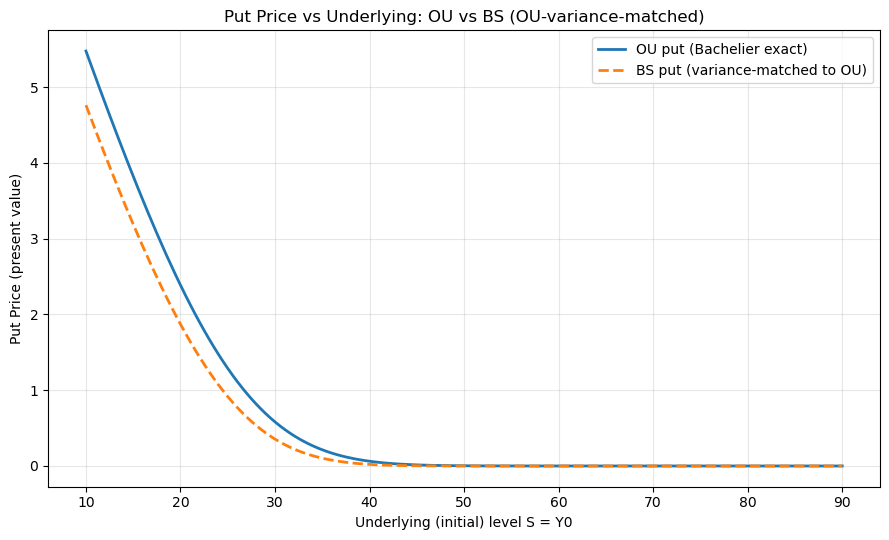

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

# Normal CDF/PDF (no SciPy)
SQRT2 = np.sqrt(2.0); SQRT2PI = np.sqrt(2.0*np.pi)
def norm_cdf(x): x=np.asarray(x,float); return 0.5*(1.0+np.vectorize(erf)(x/SQRT2))
def norm_pdf(x): x=np.asarray(x,float); return np.exp(-0.5*x**2)/SQRT2PI

# OU moments
def ou_moments(T, theta, mu, sigma, Y0):
    Y0 = np.asarray(Y0,float)
    mT = mu + (Y0 - mu)*np.exp(-theta*T)
    sT = np.sqrt((sigma**2)/(2*theta)*(1 - np.exp(-2*theta*T)))
    return mT, float(sT)

# Bachelier (normal) put for X~N(m,s^2)
def bachelier_put_from_normal(m, s, K):
    m = np.asarray(m,float); K=float(K)
    if s <= 0: return np.maximum(K - m, 0.0)
    d = (K - m)/s
    return (K - m)*norm_cdf(d) + s*norm_pdf(d)

# Vectorised BS put for arrays S0, sigma (same shape), scalar K
def bs_put_price_vec(S0, K, r, sigma, T):
    S0 = np.asarray(S0,float); sigma=np.asarray(sigma,float); K=float(K)
    prices = np.empty_like(S0,float)
    mask_deg = (sigma <= 0.0) | (T <= 0.0)
    if np.any(mask_deg):
        df = np.exp(-r*T)
        prices[mask_deg] = df*np.maximum(K - S0[mask_deg], 0.0)
    mask = ~mask_deg
    if np.any(mask):
        S = S0[mask]; v = sigma[mask]*np.sqrt(T)
        d1 = (np.log(S/K) + (r + 0.5*sigma[mask]**2)*T)/v
        d2 = d1 - v
        Nd1m = norm_cdf(-d1); Nd2m = norm_cdf(-d2)
        prices[mask] = K*np.exp(-r*T)*Nd2m - S*Nd1m
    return prices

# Parameters (adjust as needed)
r, T = 0.02, 1.0
theta, mu, sigma_ou = 1, 50.0, 5.0
K = 40.0
S_values = np.linspace(10, 90, 161)  # X-axis

# OU pricing
mT, sT = ou_moments(T, theta, mu, sigma_ou, S_values)
B_T = np.exp(r*T)
m_star, s_star = mT/B_T, sT/B_T
ou_put = bachelier_put_from_normal(m_star, s_star, K)

# BS matched to OU
sigma_bs = np.full_like(mT, np.nan, float)
valid = mT > 0
sigma_bs[valid] = np.sqrt((1.0/T)*np.log(1.0 + (sT/mT[valid])**2))
S0_bs = m_star
bs_put = bs_put_price_vec(S0_bs, K, r, sigma_bs, T)

# Plot
plt.figure(figsize=(9,5.5))
plt.plot(S_values, ou_put, label='OU put (Bachelier exact)', lw=2)
plt.plot(S_values, bs_put, '--', label='BS put (variance-matched to OU)', lw=2)
plt.xlabel('Underlying (initial) level S = Y0'); plt.ylabel('Put Price (present value)')
plt.title('Put Price vs Underlying: OU vs BS (OU-variance-matched)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig('ou_vs_bs_put_vs_underlying.png')

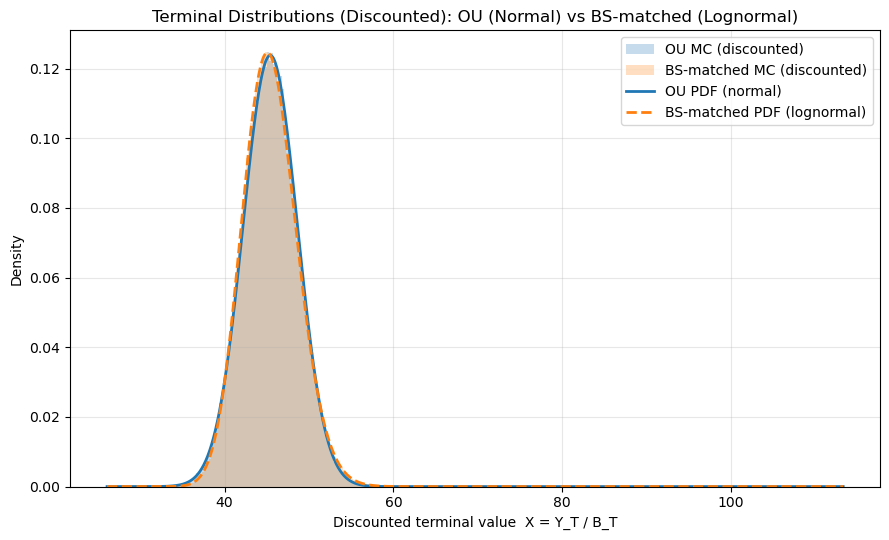

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

# --- Normal helpers (no SciPy)
SQRT2 = np.sqrt(2.0); SQRT2PI = np.sqrt(2.0*np.pi)
def norm_cdf(x): x = np.asarray(x,float); return 0.5*(1.0 + np.vectorize(erf)(x/SQRT2))
def norm_pdf(x): x = np.asarray(x,float); return np.exp(-0.5*x**2)/SQRT2PI

# --- OU moments at T
def ou_moments(T, theta, mu, sigma, Y0):
    Y0 = np.asarray(Y0,float)
    mT = mu + (Y0 - mu)*np.exp(-theta*T)
    sT = np.sqrt((sigma**2)/(2.0*theta)*(1 - np.exp(-2.0*theta*T)))
    return mT, float(sT)

# Parameters (consistent with cell 1)
r, T = 0.02, 1.0
theta, mu, sigma_ou = 1.0, 50.0, 5.0
Y0 = 40.0
B_T = np.exp(r*T)

# OU discounted terminal: X = Y_T/B_T ~ N(m*, s*^2)
mT, sT = ou_moments(T, theta, mu, sigma_ou, Y0)
m_star, s_star = mT/B_T, sT/B_T

# Grid for PDFs (cover normal support and lognormal right skew)
left = max(0.0, m_star - 6*s_star)
right = (m_star + 6*s_star) * 1.75
x = np.linspace(left, right, 1500)

# OU (normal) PDF
z = (x - m_star) / s_star
pdf_ou = norm_pdf(z) / s_star

# BS-matched: annualised vol sigma_bs such that lognormal has mean m_star, var s_star^2
# total vol over T = sigma_bs * sqrt(T)
sigma_bs = np.sqrt(np.log(1 + (s_star/m_star)**2) / T) if m_star > 0 else np.nan
if np.isfinite(sigma_bs):
    sig_total = sigma_bs * np.sqrt(T)
    mu_L = np.log(m_star) - 0.5*sig_total**2
    pdf_bs = np.where(
        x > 0,
        (1.0/(x*sig_total*np.sqrt(2*np.pi))) * np.exp(-(np.log(x)-mu_L)**2/(2*sig_total**2)),
        0.0,
    )
else:
    sig_total = np.nan
    pdf_bs = np.zeros_like(x)

# Monte Carlo samples for both
rng = np.random.default_rng(123)
N = 300_000
X_ou = m_star + s_star * rng.standard_normal(N)
X_bs = np.exp(mu_L + sig_total * rng.standard_normal(N)) if np.isfinite(sigma_bs) else np.zeros(N)

# Plot
fig, ax = plt.subplots(figsize=(9,5.5))
ax.hist(X_ou, bins=120, density=True, alpha=0.25, color='tab:blue', label='OU MC (discounted)')
ax.hist(X_bs, bins=120, density=True, alpha=0.25, color='tab:orange', label='BS-matched MC (discounted)')
ax.plot(x, pdf_ou, color='tab:blue', lw=2, label='OU PDF (normal)')
ax.plot(x, pdf_bs, color='tab:orange', lw=2, ls='--', label='BS-matched PDF (lognormal)')
ax.set_xlabel('Discounted terminal value  X = Y_T / B_T')
ax.set_ylabel('Density')
ax.set_title('Terminal Distributions (Discounted): OU (Normal) vs BS-matched (Lognormal)')
ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout()
plt.savefig('terminal_distributions_ou_vs_bs_discounted.png')


In [3]:
import numpy as np

# ===============================
# Utilities to compute moments
# ===============================

def raw_moments_from_samples(x, max_order=4):
    """Return raw moments E[X^k] for k=1..max_order from data x."""
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        raise ValueError("Empty sample")
    return {f"m{k}": float(np.mean(x**k)) for k in range(1, max_order+1)}

def central_moments_from_samples(x, max_order=4):
    """Return central moments mu_k = E[(X - E[X])^k] for k=1..max_order from data x."""
    x = np.asarray(x, dtype=float)
    mu = float(np.mean(x))
    moments = {"mu1": 0.0}
    for k in range(2, max_order+1):
        moments[f"mu{k}"] = float(np.mean((x - mu)**k))
    return moments

def standardized_moments_from_samples(x):
    """Return mean, variance, skewness, excess kurtosis from samples."""
    x = np.asarray(x, dtype=float)
    mu = float(np.mean(x))
    c2 = float(np.mean((x - mu)**2))
    c3 = float(np.mean((x - mu)**3))
    c4 = float(np.mean((x - mu)**4))
    if c2 <= 0:
        raise ValueError("Variance is zero or negative; cannot standardize.")
    return {
        "mean": mu,
        "variance": c2,
        "skewness": float(c3 / c2**1.5),
        "excess_kurtosis": float(c4 / c2**2 - 3.0),
    }

# ===============================
# Construct OU vs BS-matched discounted terminal samples
# ===============================

def ou_bs_discounted_samples(N=300_000, r=0.02, T=1.0, theta=1.0, mu=50.0, sigma_ou=5.0, Y0=40.0, seed=123):
    """Generate samples of discounted terminal X = Y_T / B_T for
    OU (normal) and BS-matched (lognormal) distributions.
    sigma_bs in params is the annualised BS vol.
    """
    rng = np.random.default_rng(seed)
    B_T = np.exp(r*T)

    # OU terminal moments
    mT = mu + (Y0 - mu) * np.exp(-theta*T)
    sT = np.sqrt((sigma_ou**2)/(2*theta) * (1 - np.exp(-2*theta*T)))

    # Discounted moments
    m_star, s_star = mT / B_T, sT / B_T

    # OU samples (normal)
    X_ou = m_star + s_star * rng.standard_normal(N)

    # BS-matched: annualised vol; lognormal std = sigma_bs * sqrt(T)
    if m_star <= 0:
        raise ValueError("m_star must be positive for lognormal mapping.")
    sigma_bs = np.sqrt(np.log(1.0 + (s_star / m_star)**2) / T)   # annualised
    sig_total = sigma_bs * np.sqrt(T)
    mu_L = np.log(m_star) - 0.5 * sig_total**2
    X_bs = np.exp(mu_L + sig_total * rng.standard_normal(N))

    params = {"m_star": m_star, "s_star": s_star, "sigma_bs": float(sigma_bs), "mu_L": float(mu_L)}
    return X_ou, X_bs, params

# ===============================
# Compute and print moments side-by-side
# ===============================
X_ou, X_bs, params = ou_bs_discounted_samples()

raw_ou = raw_moments_from_samples(X_ou, 4)
raw_bs = raw_moments_from_samples(X_bs, 4)
cen_ou = central_moments_from_samples(X_ou, 4)
cen_bs = central_moments_from_samples(X_bs, 4)
std_ou = standardized_moments_from_samples(X_ou)
std_bs = standardized_moments_from_samples(X_bs)

def p(label, d):
    print(label)
    for k, v in d.items():
        print(f"  {k:<16}: {v:,.6f}")
    print()

print("\n=== Discounted terminal X = Y_T / B_T ===")
print(f"Params: m*={params['m_star']:.6f}, s*={params['s_star']:.6f}, sigma_bs (ann.)={params['sigma_bs']:.6f}\n")

p("OU (Normal) — RAW moments (E[X^k]):", raw_ou)
p("BS-matched (Lognormal) — RAW moments (E[X^k]):", raw_bs)
p("OU (Normal) — CENTRAL moments (E[(X-E[X])^k]):", cen_ou)
p("BS-matched (Lognormal) — CENTRAL moments (E[(X-E[X])^k]):", cen_bs)
p("OU (Normal) — STANDARDISED:", std_ou)
p("BS-matched (Lognormal) — STANDARDISED:", std_bs)

print("Summary (central moments):")
print(f"  OU: mu2={cen_ou['mu2']:.6f}, mu3={cen_ou['mu3']:.6f}, mu4={cen_ou['mu4']:.6f}")
print(f"  BS: mu2={cen_bs['mu2']:.6f}, mu3={cen_bs['mu3']:.6f}, mu4={cen_bs['mu4']:.6f}")



=== Discounted terminal X = Y_T / B_T ===
Params: m*=45.403984, s*=3.222500, sigma_bs (ann.)=0.070885

OU (Normal) — RAW moments (E[X^k]):
  m1              : 45.407810
  m2              : 2,072.228722
  m3              : 95,036.070233
  m4              : 4,379,767.409655

BS-matched (Lognormal) — RAW moments (E[X^k]):
  m1              : 45.400911
  m2              : 2,071.618409
  m3              : 95,002.523938
  m4              : 4,378,650.686804

OU (Normal) — CENTRAL moments (E[(X-E[X])^k]):
  mu1             : 0.000000
  mu2             : 10.359497
  mu3             : -0.102373
  mu4             : 321.732305

BS-matched (Lognormal) — CENTRAL moments (E[(X-E[X])^k]):
  mu1             : 0.000000
  mu2             : 10.375677
  mu3             : 7.030256
  mu4             : 331.633148

OU (Normal) — STANDARDISED:
  mean            : 45.407810
  variance        : 10.359497
  skewness        : -0.003070
  excess_kurtosis : -0.002099

BS-matched (Lognormal) — STANDARDISED:
  mean   